# **CESM amip water tracer - Sanity checks**
data every months from 1979 to 2005 : first year dropped,
verifications of temperature, dimension check, 
tracer coherence (sum of the lan tracers = all land tracers), and integration function choice

This notebook integrates the water vapour tracers data and stores it. It is therefore necessary to the next notebook plots 


## **Initial Set Up-related**

### Imports

In [18]:
%matplotlib inline
########## OS Interaction ##########
import os
import sys
import cftime

########## General ##########
import numpy as np
import netCDF4 as nc
import xarray as xr
import scipy as sp
import pandas as pd
import numpy as np
import numpy.ma as ma
import matplotlib.colors as colors 
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import ticker
from matplotlib import gridspec
import dask
import dask.bag as db
from dask.diagnostics import ProgressBar

########## Cartopy+ Shapely ##########
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry.polygon import LinearRing
from mpl_toolkits.axes_grid1 import make_axes_locatable


### Function Definitions

In [19]:
# Overall: creates a new local mapping function that doesn't use basemap
def quick_map(mapdata,lat,lon,title=None,cb_ttl=None,cmap=None,clim=None,
              filepath=None,show=None,sigmask=None,p=None,
              do_zonal=None,
              outside_color = None, outside_val = None,extend='both'):

    # Makes 2 subplots: one for map, one for zonal average next to it
    fig = plt.figure(figsize=(8,7))

    # Specifies a Robinson projection map
    ax = plt.axes(projection=ccrs.Robinson())

    # Draws coastlines
    ax.coastlines()
    
    # Sets the view to be the entire globe
    ax.set_global()

    # Creates a cyclic point to ensure longitude plots smoothly 
    cyclic_data, cyclic_lons = add_cyclic_point(mapdata,coord=lon)

    # Plots the data as a coloured mesh
    cs = plt.pcolormesh(cyclic_lons, lat, cyclic_data,
                    transform=ccrs.PlateCarree())

    # If a cmap (colour map) is specified, copy and use itElse, copy and use the viridis cmap
    if cmap:
        plt.set_cmap (cmap.copy())
    else:
        plt.set_cmap(plt.cm.RdBu_r.copy())
    
    # If a title is specified, use it (also sets the font size and position)
    if title:
        plt.title(title,fontsize=20,y=1.05)

    # If a clim (colour limit) is specified, use it
    if clim:
        plt.cm.ScalarMappable.set_clim(cs,vmin = clim[0],vmax = clim[1])

    # Sets the colour bar parameters
    cbar = plt.colorbar(ax=ax,orientation='horizontal',extend=extend,pad=.02, shrink=0.9)
    cbar.ax.tick_params(labelsize=18) 

    # If a cb_ttl (colour bar title) is specified, use it
    if cb_ttl:
        cbar.set_label(cb_ttl,fontsize=20)

    # Sets cm to the cmap
    cm = plt.get_cmap()

    # Sets the alpha value
    ax.patch.set_alpha(0.0)

    # If show is specified, show the plot
   # if show:
   #     plt.show()

    # If filepath is specified, save the figured to the file path
    if filepath:
        fig.savefig(filepath+'.png',dpi=300,facecolor=None,edgecolor=None,bbox_inches='tight',transparent=True,pad_inches=0.01)

    # Closes the plot
    #plt.close()

    # Returns the figure
    return fig,ax,cs,cbar,cm

##########

# Overall: unstacks time for an input data set
def unstack_time(ds_in):

    # Groups by year or months , calculates the mean, then takes/assigns the resulting values
    years = ds_in.groupby('time.year').mean('time').year
    months = ds_in.groupby('time.month').mean('time').month

    # Makes a pandas MultiIndex that is years x months
    midx = pd.MultiIndex.from_product([years.values,months.values], names=("year","month"))

    # Creates a temporary data set copy from ds_in, multiindex yxm and assign it 
    ds_temp = ds_in.copy()
    ds_temp = ds_temp.assign_coords({'time':midx})
    ds_out = ds_temp.unstack()
    return ds_out

##########

# Overall: creates a vertical integral function
def vert_integral(da):
    if 'lev' not in da.dims:
        return da  # Already integrated or 2D variable
    da2 = da.assign_coords({'lev':da.lev.values*100}) #hPA to Pa
    
    integrated = (da2.integrate('lev')/9.81) # integrate while /g
    return integrated

# Overall: creates a  BETTER vertical integral function
def vert_integral_ilev(ds,var):

    da_lev = ds.lev.copy()
    da_ilev = ds.ilev.copy()
    dlev = da_ilev.ilev[1::].values - da_ilev.ilev[0:-1].values

    # Create a DataArray with dimension names and coordinate labels
    da_dlev = xr.DataArray(dlev*100., dims=("lev"),coords={"lev": da_lev.values})
    delta_pressure_levels = (ds[var].copy()*0.0+1.0)*da_dlev
    mass_weighted_vapor = ds[var] * delta_pressure_levels # mass weighted 'q'
    
    # Vertically Integrated Vapor ( /gravitational acceleration)
    integrated = mass_weighted_vapor.sum(dim="lev")/9.80665 
    return integrated

# Overall: creates a vertical integration function accounting for totpography and surface pressure
def vert_int_hybrid(ds, var, ds_hybrid):
    g    = 9.80665   # m/s²
    P0   = 100000.   # Pa  (standard reference pressure)

    q    = ds[var]
    PS   = ds_hybrid['PS']    # surface pressure  (Pa)
    hyai = ds_hybrid['hyai']  # interface A coefficients
    hybi = ds_hybrid['hybi']  # interface B coefficients

    # Interface pressures at every grid point & level interface
    P_i = hyai * P0 + hybi * PS          # shape: (time, ilev, lat, lon)

    # Pressure thickness of each model layer
    dp = P_i.diff(dim='ilev')            # shape: (time, ilev-1, lat, lon)
    dp = dp.transpose("time", "ilev", "lat", "lon")

    # Copy dp into a DataArray that shares 'lev' dim with q
    dp_lev = ds[var].copy() * 0.0
    dp_lev.values = dp.values

    # Hydrostatic column integral: Σ (q·dp) / g
    layer_int = (q * dp_lev) / g
    total_int = layer_int.sum(dim='lev', skipna=True)
    return total_int
    

### Path Definitions

In [20]:
# Data Path
data_dir =  '/scratch/st-mlague-1/mlague/data/iCESM/'

### Variable Definitions

In [21]:
# Creates a list of atmospheric variables
atm_vars = ['TS','TREFHT','PRECC', 'LHFLX','PRECL','Q','TMQ','LNDV','NPV', 'NAV', 'EUV', 'EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV', 'SPV'] #all the variables we want
static_vars = ['hyai', 'hybi','PS'] # variables for the hybrid integration

# tracer list,and dictionary associating it with a name
tracer_realnames = ['Q','LNDV','NPV', 'NAV', 'EUV','EAV', 'CSAV', 'CAFV','MARV', 'SAV', 'SAFV', 'AUSV', 'SPV']
tracer_shortnames = ['All Land and Oceans','All Land', 'North Pole', 'North America', 'Europe and Northern Africa', 'Eastern Asia', 'Central South America', 'Central Africa', 'Maritime Continent', 'South America', 'South Africa', 'Australia', 'South Pole']
tracer_dict_reversed = dict(zip(tracer_realnames, tracer_shortnames))

# case list, dictionary associating it with a name
case_list = ['icesm_continents_sst'] #case list
short_list=['amip'] # case list names
short_names = dict(zip(case_list, short_list))


### Dictionary Definitions

In [22]:
# Creates an empty data set dictionary
ds_dict = {}

# Creates an empty time series dictionary for the atmospheric variables
ts_dict_atm = {}

for case in case_list:
    # Defines the time series directory name for the case
    ts_dir = Path(data_dir) / case / 'TimeSeries'

    # Build the list of atm files with pathlib,
    file_list_atm = []
    ds_static_list = []
    for var in atm_vars:
        file_path = f'{case}.cam.h0.ts.0-end.{var}.nc'
        files = sorted(ts_dir.glob(file_path))

        if not files:
            print(f'oh no, no variables for {var}')
        else:
            for file in files:
                    file_list_atm.append(file)
        print( 'got the data from', var) 
        
    # static variables for the integral function
    for var in static_vars:
        file_path = f'{case}.cam.h0.ts.0-end.{var}.nc'
        files = sorted(ts_dir.glob(file_path))
        if not files:
            print(f'oh no, no file for {var}')
        else:
            ds_static_list.append(xr.open_dataset(files[0], engine='netcdf4'))  # ONE file, ONE var
        print('got the data from', var)
        
    # Open the variables all at once without dropping any years
    ds_temp_atm = xr.open_mfdataset(file_list_atm, engine='netcdf4', compat='override',chunks={'time': 36, 'lev': 30, 'lat': 48, 'lon': 72} )
    ds_temp_atm_short = ds_temp_atm.isel(time=slice(11,323)) # Drops the first year
    ds_temp_static = xr.merge(ds_static_list)
    ds_static_coeffs = ds_temp_static[['hyai', 'hybi', 'P0']]
    ds_static_PS = ds_temp_static['PS'].isel(time=slice(11, 323))
    
    # Merge everything
    ds_temp_atm_short = xr.merge([ds_temp_atm_short, ds_static_coeffs, ds_static_PS], join='override')

    print('data put together and cut!')
    short = short_names[case]
    ds_temp_atm_short.attrs['title'] = short  # assign the short name as the title
    ts_dict_atm[short] = ds_temp_atm_short.copy()
    del ds_temp_atm, ds_temp_atm_short  # Deletes the temporary data sets

got the data from TS
got the data from TREFHT
got the data from PRECC
got the data from LHFLX
got the data from PRECL
got the data from Q
got the data from TMQ
got the data from LNDV
got the data from NPV
got the data from NAV
got the data from EUV
got the data from EAV
got the data from CSAV
got the data from CAFV
got the data from MARV
got the data from SAV
got the data from SAFV
got the data from AUSV
got the data from SPV
got the data from hyai
got the data from hybi
got the data from PS
data put together and cut!


### Weighting and dimension check

In [23]:
for case in ts_dict_atm.keys():
    # Print the case name, time values, start and end 
    print ('name =',case)
    print('time lenght divided by 12 = number of years = ',len(ts_dict_atm[case].time.values)/12)
    print('start =',ts_dict_atm[case].time.values[0],'       end =' ,ts_dict_atm[case].time.values[-1])

    print('time lenght =',len(ts_dict_atm[case].time.values))
    print('lat dim =',len(ts_dict_atm[case].lat.values))
    print('lon dim =',len(ts_dict_atm[case].lon.values))
    print ('lev dim =',len(ts_dict_atm[case].lev.values))

name = amip
time lenght divided by 12 = number of years =  26.0
start = 1980-01-01 00:00:00        end = 2005-12-01 00:00:00
time lenght = 312
lat dim = 96
lon dim = 144
lev dim = 30


In [24]:
# Weights the latitude, renames it to "weights", then prints the value
weights = np.cos(np.deg2rad(ts_dict_atm['amip']['TS'].lat))
weights.name = "weights"

## **Data Analysis-related**

### Temperature plots

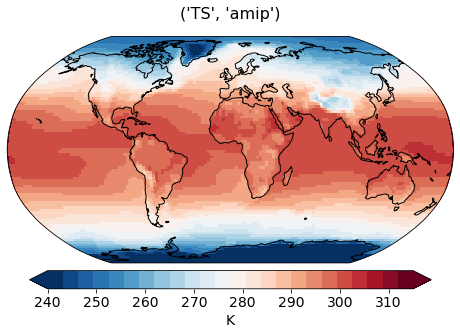

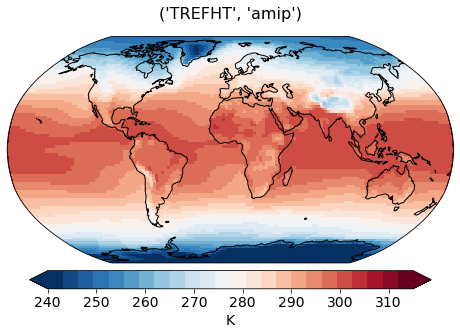

In [71]:
# Overall: creates a map plot of the different temperatures
for case in short_list:

    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    for run in ['TS','TREFHT']: #radiative temperature and reference height temprature
        clim=[240,315.]

        # Finds the difference between the case's data and the control's data
        mapdata = (ds_case[run].mean('year')) #- (ds_ctrl['TS'].mean('year'))

        # Sets the plot's title
        ttl = run,case

        # Sets the cmap colour
        cmap = plt.cm.get_cmap('RdBu_r',24)


        # Uses the quick_map function (defined previously) to create the plot
        quick_map(mapdata,mapdata.lat,mapdata.lon,title=ttl,cb_ttl='K',
                  cmap=cmap,clim=clim,
                      filepath=None,show=1,sigmask=None,p=None,
                      do_zonal=None,
                      outside_color = None, outside_val = None,extend='both')

### tracer Verifications : is sum of lands= all land  integrated Q=TMQ

done: NPV
done: NAV
done: EUV
done: EAV
done: CSAV
done: CAFV
done: MARV
done: SAV
done: SAFV
done: AUSV
done: SPV
[########################################] | 100% Completed | 18.5s


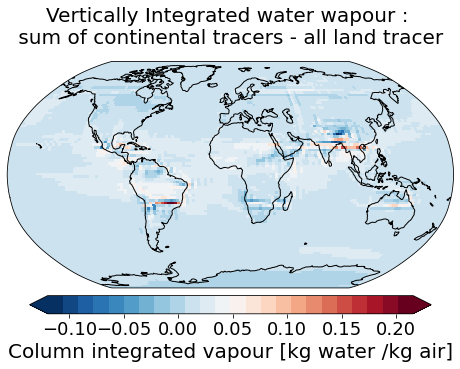

In [25]:
# SANITY CHECK :  verification : all vapor = land vapor  
#------- CAUTION : needs many nodes to run---------------#
for case in short_list:
    sum_data_integrated=0
    
    for run in ['NPV', 'NAV', 'EUV','EAV', 'CSAV', 'CAFV','MARV', 'SAV', 'SAFV', 'AUSV', 'SPV'] :
        #clim=[240,315.]
        data_integrated = vert_integral_ilev(ts_dict_atm[case],run)       # shape: (96, 144, 276) lat and lon and time 
        var_mean = data_integrated.mean('time')  # shape: ( 96, 144) 2D spacial
        sum_data_integrated += var_mean         #sum of all water vapour tracers 
        print(f'done: {run}')
   
    all_land_data_integrated_vert = vert_integral_ilev(ts_dict_atm[case],'LNDV')  # spacial integration of the all land tracer
    all_land_data_integrated =all_land_data_integrated_vert.mean('time')# shape: (96,144) 2D spacial
    mapdata = (sum_data_integrated) - (all_land_data_integrated) # comparing if it equals the general all land tracer

    # Sets the plot's title and map colour
    ttl = f'Vertically Integrated water vapour : \n sum of continental tracers - all land tracer '
    cmap = plt.cm.get_cmap('RdBu_r',24)

    with ProgressBar():
        mapdata = mapdata.compute()

    quick_map(mapdata.values ,mapdata.lat,mapdata.lon,title=ttl,cb_ttl='Column integrated vapour [kg water /kg air]',cmap=cmap,clim=None,filepath=None,show=1,sigmask=None,p=None,do_zonal=None, outside_color = None, outside_val = None,extend='both')


### Integration function comparison: integrated Q - TMQ

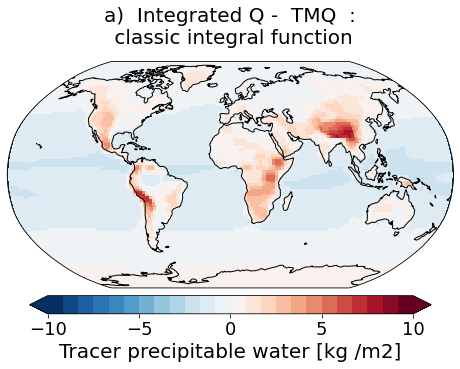

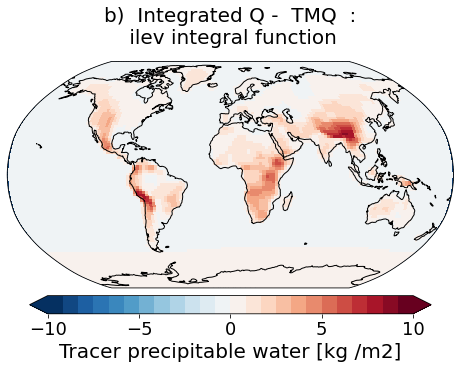

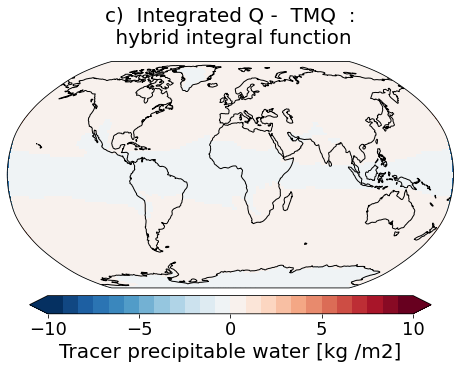

In [11]:
#integrated Q- TMQ verification 
short_list= ['amip']
for case in short_list:
    #TMQ in lon, lat:
    mean_integrated_vapor =ts_dict_atm[case]['TMQ'].mean('time') 
    #Intrgration of Q in lon,lat with 3 different intrgation functions
    tracer = 'Q' 
    da_int ={
        'classic' : (vert_integral(ts_dict_atm[case][tracer])),
        'ilev' : (vert_integral_ilev(ts_dict_atm[case],tracer)),
        'hybrid': (vert_int_hybrid(ts_dict_atm[case], tracer, ts_dict_atm[case]))}
    
    letters= ['a)','b)','c)']
    i=0
    for da in ['classic','ilev','hybrid']:
        sum_data_integrated = da_int[da].mean('time')  # Q shape( lon, lat)
        mapdata = (sum_data_integrated)- (mean_integrated_vapor) # comparing if it equals the general all land tracer
  
        # Sets the plot's title and map colour
        ttl = f'{letters[i]}  Integrated Q -  TMQ  :\n {da} integral function'
        i=i+1
        cmap = plt.cm.get_cmap('RdBu_r',24)
        clim= [-10,10]
        # plot of integrated Q-TMQ
        quick_map(mapdata.values ,mapdata.lat,mapdata.lon,title=ttl,cb_ttl='Tracer precipitable water [kg /m2]',cmap=cmap, clim=clim,
                  filepath=None,show=1,sigmask=None,p=None,do_zonal=None, outside_color = None, outside_val = None,extend='both')

        plt.savefig(f'q-tmq{da}.svg')
        #print (da, 'maximum= ',float(np.abs(mapdata).max()))
        

### integration and storage with hybrid function

In [ ]:
#overall: intragrate every tracer already to gain time in later cells 
# Caution: requires time and mutiple nodes, to run a single time for all the notebooks
integrated_dict = {}
for tracer in tracer_realnames:
    integrated_dict[tracer] = vert_int_hybrid(ts_dict_atm['amip'], tracer, ts_dict_atm['amip']).compute()  
    integrated_dict[tracer].to_netcdf("vert_int_output/"+tracer+".nc")